# Extraction of CKM Angle $\gamma$ from $B \to DK$ Decays
## Square Dalitz Plot (SDP) Pipeline

This notebook extracts $\gamma$, $\delta_B$, and $r_B$ from $B^\pm \to [K_S\pi^+\pi^-]_D K^\pm$
decays using an unbinned maximum-likelihood fit in the **Square Dalitz Plot (SDP)**.
All densities are evaluated directly in SDP measure — no Jacobian conversion is required.

### Key conventions
- **Resonant pair**: $\pi^+\pi^-$ &nbsp;(`idx=(2,3,1)` with $s_{23}$ driving $m'$)
- **CP symmetry**: swapping $\pi^+\leftrightarrow\pi^-$ maps $(m', \theta') \to (m', 1-\theta')$
- **Flows trained** under the same $\pi^+\pi^-$ SDP convention (`flavor_SDP_sym_2e6/`,
  `even_SDP_sym_2e6/`, `odd_SDP_sym_2e6/`)

### Analysis steps
1. Load three normalising-flow ensembles (flavor $D^0$, CP-even, CP-odd)
2. Compute CP normalisation constants $\Gamma_\pm$
3. Generate pseudo-data $B^\pm$ samples at Benchmark A ($r_B = 0.1$)
4. Compute per-point interference terms $K$, $\bar K$, $C$, $S$ in SDP measure
5. Enforce the physicality constraint $|C| \le \sqrt{K\bar K}$ (KNN smoothing)
6. Unbinned ML fit with iminuit -> $r_B$, $\delta_B$, $\gamma$
7. Ensemble fits for flow-model uncertainty estimation

---
## 1. Physics Background

### Decay rates in the Square Dalitz Plot
For $B^\mp \to [K_S\pi^+\pi^-]_D K^\mp$, the differential decay rate in SDP coordinates $(m',\theta')$ is (Eq. 38):

$$
\tilde{p}^\mp(m',\theta') = \bar K + r_B^2 K \pm 2r_B\bigl[C\cos(\delta_B\mp\gamma) \mp S\sin(\delta_B\mp\gamma)\bigr]
$$

where $K$ and $\bar K$ are the normalised SDP densities of the $D^0$ decay amplitude (Eq. 23):

$$
K(m',\theta') = \frac{|A_D(m',\theta')|^2}{\hat\Gamma_{K_S\pi\pi}},
\qquad \bar K(m',\theta') = K(m', 1-\theta')
$$

$A_D$ is the $D^0$ isobar amplitude and $\hat\Gamma_{K_S\pi\pi}$ normalises $K$ to unity over the SDP.
The interference terms (Eqs. 24-25) are:

$$
C(m',\theta') = \sqrt{K\bar K}\cos\Delta\phi,
\qquad S(m',\theta') = \sqrt{K\bar K}\sin\Delta\phi
$$

with $\Delta\phi = \arg A_D(m',\theta') - \arg A_D(m',1-\theta')$.

### Extracting $C$ from CP eigenstates
The CP eigenstates satisfy $|A_{D_+}|^2 - |A_{D_-}|^2 = 2\,\mathrm{Re}(A_D\bar A_D^*)$, giving (Eq. 29):

$$
C = \frac{\Gamma_+ p_+(m',\theta') - \Gamma_- p_-(m',\theta')}{\Gamma_+ + \Gamma_-}
$$

where $p_\pm$ are the normalised SDP densities of $D_{CP}^\pm$ events and $\Gamma_\pm$ are the total CP-even/odd rates.

### Physicality constraint
Cauchy-Schwarz requires $|C| \le \sqrt{K\bar K}$.
Flow imperfections can violate this; remedies are described in Sec. 9.

---
## 2. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json, time
from pathlib import Path
from scipy.spatial import KDTree

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from iminuit import Minuit

from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import (
    CompositeTransform, InverseTransform,
    PiecewiseRationalQuadraticCouplingTransform,
    RandomPermutation,
    Sigmoid,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

sns.set_style('ticks')
sns.set_context('paper', font_scale=1.4)
plt.rcParams['text.usetex'] = False  # set True if LaTeX is available


Using device: cpu


---
## 3. Helper Functions

### Coordinate conventions
We use the **$\pi^+\pi^-$ SDP** convention: `idx = (2, 3, 1)`

| quantity | expression |
|---|---|
| $s_{23} = m^2(\pi^+\pi^-)$ | $= M_D^2 + m_{K_S}^2 + 2m_\pi^2 - s_{12} - s_{13}$ |
| $m'$ | from $s_{23}$ via `MpfromM(s23, s12, 2, 3, 1)` |
| $\theta'$ | from $s_{12}$ via `TfromM(s23, s12, 2, 3, 1)` |
| $\pi^+\leftrightarrow\pi^-$ | $m'\to m'$, &nbsp;$\theta'\to 1-\theta'$ |

In [3]:
from Amplitude import DKpp, BKpp, DalitzSample, AmpSample, SquareDalitzPlot2
from DKpp import DKppCorrelated

# Particle masses
mD, mKs, mpi = 1.86483, 0.497611, 0.13957018
sdp_obj = SquareDalitzPlot2(mD, mKs, mpi, mpi)
_sum_m2  = sdp_obj.mSq[0] + sdp_obj.mSq[1] + sdp_obj.mSq[2] + sdp_obj.mSq[3]

# Isobar amplitude model
dkpp = DKpp()


# ------------------------------------------------------------
def _finite_pos(x, eps=1e-14):
    """Replace non-finite values with eps; enforce x >= eps."""
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    return np.maximum(x, eps)


# ------------------------------------------------------------
def dp_to_sdp(points_dp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Convert Dalitz-plot (s12, s13) -> SDP (m', theta').

    With idx=(2,3,1) the resonant pair is pi+pi-, so
        s_ij = s23 = M^2 + mK^2 + 2*mpi^2 - s12 - s13
        s_ik = s12
    """
    i, j, k = idx
    s12, s13 = points_dp[:, 0], points_dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    mp = np.vectorize(lambda a, b: sdp_obj.MpfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    tp = np.vectorize(lambda a, b: sdp_obj.TfromM(a, b, i, j, k),  otypes=[float])(s23, s12)
    return np.column_stack([mp, tp])


def sdp_to_dp(points_sdp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Convert SDP (m', theta') -> Dalitz-plot (s12, s13).

    M_from_MpT returns (s23, s12); we recover s13 = sum_m2 - s23 - s12.
    """
    i, j, k = idx
    out = np.empty_like(points_sdp, dtype=float)
    for n, (mp, tp) in enumerate(points_sdp):
        s23, s12 = sdp_obj.M_from_MpT(mp, tp, i, j, k)
        out[n, 0] = s12
        out[n, 1] = _sum_m2 - s23 - s12
    return out  # columns: [s12, s13]


def swap_to_other_pair_sdp(points_sdp):
    """
    Apply pi+ <-> pi- exchange in SDP coordinates.

    In the (2,3,1) convention, swapping s12 <-> s13 leaves s23 unchanged
    and flips the helicity angle, giving simply:
        m'     ->  m'          (unchanged)
        theta' ->  1 - theta'
    """
    out = np.array(points_sdp, copy=True, dtype=float)
    out[:, 1] = 1.0 - out[:, 1]
    return out


def sdp_uniform_mc(N, eps=1e-6):
    """Draw N points uniformly in [eps, 1-eps]^2 (SDP coordinates)."""
    return np.random.rand(N, 2) * (1 - 2*eps) + eps


# ------------------------------------------------------------
def mag_exact(points_sdp, dkpp_model=dkpp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Compute |A_D(s12,s13)| and 1/J at SDP grid points directly from
    the isobar model (no flow needed).

    Returns
    -------
    mag  : |A_D(s12, s13)|
    invJ : 1 / jacobian(s23, s12, 2, 3, 1)  (used in MC normalisation)
    """
    i, j, k = idx
    dp = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    J   = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k))
                    for n in range(len(points_sdp))])
    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    return np.abs(A12), _finite_pos(1.0 / J)


In [4]:
def mag_AD_from_flow(points_sdp, flow, sdp_obj=sdp_obj, idx=(2, 3, 1), device=device):
    """
    Evaluate sqrt(p_SDP) at SDP points from a single normalising flow.

    Working entirely in SDP measure: the flow density p_SDP is used
    directly.  No Jacobian conversion to Dalitz-plot units is needed.

    Returns
    -------
    mag_sdp : sqrt(p_SDP)  [SDP-measure square-root density]
    """
    pts_t = torch.from_numpy(np.ascontiguousarray(points_sdp)).float().to(device)
    flow.eval().to(device)
    with torch.no_grad():
        p_sdp = torch.exp(flow.log_prob(pts_t)).cpu().numpy()
    return np.sqrt(_finite_pos(p_sdp))


---
## 4. Dataset Class and Flow Architecture

The same architecture is used for all three flow types (flavor $D^0$, CP-even, CP-odd): a rational-quadratic neural spline flow on the unit square $[0,1]^2$.

In [5]:
class DalitzDataset(Dataset):
    def __init__(self, data):
        self.data = (torch.FloatTensor(data)
                     if isinstance(data, np.ndarray)
                     else data.float())
    def __len__(self):          return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


class MLP(nn.Module):
    """Conditioner MLP for coupling layers."""
    def __init__(self, in_features, out_features, hidden=64, layers=2, output_scale=0.30):
        super().__init__()
        feats = [nn.Linear(in_features, hidden), nn.SiLU()]
        for _ in range(layers - 1):
            feats += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*feats)
        self.head = nn.Linear(hidden, out_features)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        self.output_scale = output_scale
    def forward(self, x, context=None):
        return self.head(self.backbone(x)) * self.output_scale


def create_flow(on_unit_box=True, num_flows=12, hidden_features=128,
                num_bins=24, device=None):
    """
    Create a rational-quadratic neural spline flow on [0,1]^2.
    Architecture matches the training notebooks exactly.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dim = 2
    transforms = []

    if on_unit_box:
        sigmoid = Sigmoid()
        # Move plain tensor attributes that .to() misses
        if hasattr(sigmoid, "temperature") and isinstance(sigmoid.temperature, torch.Tensor):
            sigmoid.temperature = sigmoid.temperature.to(device)
        if hasattr(sigmoid, "eps") and isinstance(sigmoid.eps, torch.Tensor):
            sigmoid.eps = sigmoid.eps.to(device)
        transforms.append(InverseTransform(sigmoid))

    masks = [torch.tensor([1, 0], dtype=torch.bool),
             torch.tensor([0, 1], dtype=torch.bool)]

    for i in range(num_flows):
        def _conditioner(in_f, out_f, _h=hidden_features):
            return MLP(in_f, out_f, hidden=_h, layers=2)

        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=masks[i % 2],
                transform_net_create_fn=_conditioner,
                num_bins=num_bins,
                tails="linear",
                tail_bound=5.0,
                apply_unconditional_transform=False,
            )
        )
        transforms.append(RandomPermutation(features=dim))

    return Flow(
        transform=CompositeTransform(transforms),
        distribution=StandardNormal([dim]),
    )


---
## 5. Load Trained Flow Ensembles

Three ensembles of 25 flows each, all trained with `idx=(2,3,1)` (the $\pi^+\pi^-$ SDP convention):

| Ensemble | Directory | Amplitude |
|---|---|---|
| Flavor $D^0$ | `flavor_SDP_sym_2e6/` | $|A_D(s_{12},s_{13})|^2$ |
| CP-even | `even_SDP_sym_2e6/` | $|A_D + \bar A_D|^2/2$ |
| CP-odd  | `odd_SDP_sym_2e6/`  | $|A_D - \bar A_D|^2/2$ |

The ensemble average reduces statistical uncertainty from the finite training samples.

In [6]:
def load_flow(path, num_flows=12, hidden_features=128, num_bins=24, device=device):
    """Load a single flow checkpoint."""
    f = create_flow(num_flows=num_flows, hidden_features=hidden_features,
                    num_bins=num_bins, device=device)
    f.load_state_dict(torch.load(path, map_location=device))
    f.eval()
    return f


def load_ensemble(directory, n_models=25, num_flows=12,
                  hidden_features=128, num_bins=24, device=device):
    """
    Load up to n_models checkpoints from `directory/trial_seed*.pth`.
    Used by run_flow_ensemble_fits to iterate over independently trained flows.
    """
    ckpts = sorted(Path(directory).glob("trial_seed*.pth"))[:n_models]
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints in {directory}")
    flows = [load_flow(ck, num_flows, hidden_features, num_bins, device)
             for ck in ckpts]
    print(f"  Loaded {len(flows)} flows from {directory}")
    return flows


print("Loading flows...")
# Load one representative flow per type for the main benchmark fits
flow_flavor = load_flow("flavor_SDP_sym_2e6/trial_seed1.pth")
flow_even   = load_flow("even_SDP_sym_2e6/trial_seed1.pth")
flow_odd    = load_flow("odd_SDP_sym_2e6/trial_seed1.pth")
print("Done.")


Loading flows...
Done.


---
## 6. Compute CP Normalisation Constants $\Gamma_\pm$

$$
\Gamma_\pm = \int |A_D(s_{12},s_{13}) \pm A_D(s_{13},s_{12})|^2\,ds_{12}\,ds_{13}
$$

These constants appear in the formula for $C$:
$C = (\Gamma_+ p_+ - \Gamma_- p_-) / (\Gamma_+ + \Gamma_-)$

In [7]:
def compute_Gamma_pm(dkpp_model=dkpp, sdp_obj=sdp_obj,
                     idx=(2, 3, 1), n_grid=800):
    """
    Integrate |A_D +/- Abar_D|^2 / J_SDP over the unit square.

    Uses a uniform (m', theta') grid; the Jacobian 1/J converts from
    SDP measure to the physical Dalitz-plot measure.
    """
    u = np.linspace(0, 1, n_grid)
    v = np.linspace(0, 1, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])

    dp   = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))

    I_plus  = np.abs(A12 + A13s)**2
    I_minus = np.abs(A12 - A13s)**2

    # Jacobian for measure conversion
    i, j, k = idx
    s23 = _sum_m2 - s12 - s13
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k))
                  for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)

    dA = (1.0 / (n_grid - 1))**2
    Gp = np.sum(I_plus  * invJ) * dA
    Gm = np.sum(I_minus * invJ) * dA
    return Gp, Gm


print('Computing Gamma_+/-...')
Gamma_plus, Gamma_minus = compute_Gamma_pm()
print(f'  Gamma_+ = {Gamma_plus:.4f}')
print(f'  Gamma_- = {Gamma_minus:.4f}')


Computing Gamma_+/-...


c:\Users\chinh\OneDrive\Documents\GitHub\Extraction-of-Gamma-with-Normalising-flows\Amplitude.py:487: RuntimeWarning: divide by zero encountered in scalar divide
  dmp_dsij = -(1.0 / np.pi) * (1.0 / np.sqrt(one_minus_x2)) * (1.0 / (denom_m * np.sqrt(mijSq)))
c:\Users\chinh\OneDrive\Documents\GitHub\Extraction-of-Gamma-with-Normalising-flows\Amplitude.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  cosHel = -(mikSq - self.mSq[i] - self.mSq[k] - 2.0 * EiCmsij * EkCmsij) / (2.0 * self.qi * self.qk)


  Gamma_+ = 949.7867
  Gamma_- = 2008.2195


---
## 7. $B^\pm$ Sample Generation

We use one benchmark physics point:

| Benchmark | $r_B$ | $\delta_B$ | $\gamma$ |
|---|---|---|---|
| A | 0.1 | 130° | 70° |

For each charge we generate `N_exp` experimental events (from `BKpp`) and `N_mc` Monte Carlo events
drawn **uniformly in $(m',\theta')$**, used to numerically normalise the likelihood.

In [8]:
def generate_BpBm_samples(
    rB, deltaB, gamma,
    N_exp, N_mc,
    sdp_obj=sdp_obj, idx=(2, 3, 1),
):
    """
    Generate B+/B- pseudo-data and uniform SDP Monte Carlo.

    Parameters
    ----------
    rB, deltaB, gamma : float
        True physics parameters (deltaB, gamma in radians).
    N_exp : int
        Experimental events per charge.
    N_mc : int
        Uniform SDP Monte Carlo events per charge (for normalisation).

    Returns
    -------
    dict with keys: dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp
    """
    bM = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=-1)
    bP = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=+1)

    print('Generating B- data...')
    t0 = time.time()
    dataM_dp = AmpSample(bM).generate(N_exp, nbatch=20_000)
    print(f'  {len(dataM_dp):,} events in {time.time()-t0:.1f}s')

    print('Generating B+ data...')
    t0 = time.time()
    dataP_dp = AmpSample(bP).generate(N_exp, nbatch=20_000)
    print(f'  {len(dataP_dp):,} events in {time.time()-t0:.1f}s')

    dataM_sdp = dp_to_sdp(dataM_dp, sdp_obj, idx)
    dataP_sdp = dp_to_sdp(dataP_dp, sdp_obj, idx)

    mcM_sdp = sdp_uniform_mc(N_mc)
    mcP_sdp = sdp_uniform_mc(N_mc)

    return dict(dataM_sdp=dataM_sdp, dataP_sdp=dataP_sdp,
                mcM_sdp=mcM_sdp,     mcP_sdp=mcP_sdp)


---
## 8. Compute Interference Terms

For each SDP point $(m',\theta')$ we compute the following quantities, all in SDP measure:

| Symbol | Meaning |
|---|---|
| `pF` | $K(m',\theta')$ -- SDP density of $D^0$ decay from flavor flow |
| `pFsw` | $\bar K(m',\theta') = K(m',1-\theta')$ -- flavor flow at swapped point |
| `abJ` | $\sqrt{K\bar K}$ -- Cauchy-Schwarz bound on $|C|$ |
| `C` | $(\Gamma_+ p_+ - \Gamma_- p_-)/(\Gamma_+ + \Gamma_-)$ |
| `S` | $\mathrm{sign}(\sin\Delta\phi)\sqrt{K\bar K - C^2}$ |

The sign of $S$ is taken from the exact isobar-model phase difference
$\Delta\phi = \arg A_D(m',\theta') - \arg A_D(m',1-\theta')$ to avoid flow sign ambiguity.

In [10]:
def compute_interference_terms(
    points_sdp,
    flow_flavor, flow_even, flow_odd,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    Gamma_plus=1.0, Gamma_minus=1.0,
    idx=(2, 3, 1), device=device,
):
    """
    Compute per-point interference quantities using a single flow per type.
    All quantities are in SDP measure — no Jacobian factor needed.

    In the pi+pi- convention, Abar_D is obtained by evaluating the flavor
    flow at the swapped point (m', 1-theta').
    """
    # sqrt(p_SDP) directly from the flow — no Jacobian
    mag12 = mag_AD_from_flow(points_sdp, flow_flavor, sdp_obj, idx, device)

    # Abar_D: flavor flow at swapped point
    pts_swap = swap_to_other_pair_sdp(points_sdp)
    mag13 = mag_AD_from_flow(pts_swap, flow_flavor, sdp_obj, idx, device)

    mag12 = _finite_pos(mag12)
    mag13 = _finite_pos(mag13)
    pF    = mag12**2   # p_SDP at the data point
    pFsw  = mag13**2   # p_SDP at the swapped point
    abJ   = mag12 * mag13

    # C from CP-even and CP-odd flows (SDP measure)
    p_even = _finite_pos(mag_AD_from_flow(points_sdp, flow_even, sdp_obj, idx, device))**2
    p_odd  = _finite_pos(mag_AD_from_flow(points_sdp, flow_odd,  sdp_obj, idx, device))**2
    C = (Gamma_plus * p_even - Gamma_minus * p_odd) / (Gamma_plus + Gamma_minus)

    # Sign of S from exact isobar phases (unchanged)
    dp   = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    dphi = (np.angle(A12) - np.angle(A13s) + np.pi) % (2*np.pi) - np.pi
    S = np.sign(np.sin(dphi)) * np.sqrt(np.maximum(abJ**2 - C**2, 0.0))

    C = np.where(np.isfinite(C), C, 0.0)
    S = np.where(np.isfinite(S), S, 0.0)

    return dict(
        pF   = _finite_pos(pF),
        pFsw = _finite_pos(pFsw),
        C    = C,
        S    = S,
        abJ  = abJ,
        # J omitted: all quantities are in SDP measure
    )


---
## 9. Enforcing the Physicality Constraint $|C| \le \sqrt{K\bar K}$

Flow imperfections can produce $|C| > \sqrt{K\bar K}$, which violates the Cauchy-Schwarz inequality.
We provide four remedies, all operating on the already-computed interference-term dictionaries
with no additional flow evaluations:

| Method | Strategy |
|---|---|
| **Hard cut** | Remove violating points (may bias normalisation if violations cluster) |
| **Clamp** | Clip $C$ to $[-\sqrt{K\bar K},\,\sqrt{K\bar K}]$ and recompute $S$ |
| **KNN smoothing** | Average $C$ and $\sqrt{K\bar K}$ over $K$ nearest SDP neighbours until $|C_{\rm avg}| \le \sqrt{K\bar K}_{\rm avg}$; discard if $K > K_{\max}$ |
| **KNN smoothing v2** | Average $C$ over $K$ nearest neighbours drawn from the **uniform MC** (unbiased reference); $\sqrt{K\bar K}$ kept fixed; discard if $K > K_{\max}$ |
| **Nearest valid point** | Copy $C$, $\sqrt{K\bar K}$, $S$ from the nearest precomputed SDP point that already satisfies the constraint |

**KNN v2** avoids the phase-space bias of the $B$-decay data by using uniform MC as the neighbour pool.

In [32]:
# --- Method 1: Hard cut -------------------------------------------------
def apply_hard_cut(t):
    """
    Remove points where |C| > abJ.
    Simple but reduces effective statistics and biases the normalisation
    if violations cluster in specific kinematic regions.
    """
    mask = np.abs(t['C']) <= t['abJ']
    n_kept = mask.sum()
    n_tot  = len(mask)
    print(f'    Hard cut: {n_tot - n_kept} / {n_tot} removed '
          f'({100*(n_tot-n_kept)/n_tot:.1f}%)')
    return {key: val[mask] for key, val in t.items()}


# --- Method 2: Clamp ----------------------------------------------------
def apply_clamp(t):
    """
    Project C onto [-abJ, +abJ] then recompute S preserving its sign.
    All points are kept; constraint is enforced exactly.
    """
    t = {k: v.copy() for k, v in t.items()}
    n_viol = (np.abs(t['C']) > t['abJ']).sum()
    sign_S = np.sign(t['S'])
    t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
    t['S'] = sign_S * np.sqrt(np.maximum(t['abJ']**2 - t['C']**2, 0.0))
    print(f'    Clamp: {n_viol} / {len(t["C"])} points clamped '
          f'({100*n_viol/len(t["C"]):.1f}%)')
    return t


# --- Method 3: KNN smoothing --------------------------------------------
def apply_knn_smoothing(t, sdp_points, K_init=5, K_max=200):
    """
    For each violating point, average C and abJ over its K nearest
    SDP-space neighbours until |C_avg| <= abJ_avg.
    K is doubled each round; points still violated at K_max are discarded.

    Parameters
    ----------
    t         : dict from compute_interference_terms
    sdp_points: (N,2) array of the SDP coordinates of these points
    K_init    : starting number of neighbours
    K_max     : give up and discard point if K exceeds this
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    KNN: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), smoothing...')

    tree     = KDTree(sdp_points)
    keep     = np.ones(len(C), dtype=bool)
    viol_idx = np.where(violated)[0]

    for pt in viol_idx:
        K = K_init
        found = False
        while K <= K_max:
            _, nbrs = tree.query(sdp_points[pt], k=K)
            c_s   = np.concatenate([[C[pt]],   C[nbrs]]).mean()
            abJ_s = np.concatenate([[abJ[pt]], abJ[nbrs]]).mean()
            if np.abs(c_s) <= abJ_s:
                C[pt]   = c_s
                abJ[pt] = abJ_s
                found = True
                break
            K *= 2
        if not found:
            keep[pt] = False

    # Recompute S at smoothed points
    smoothed = viol_idx[keep[viol_idx]]
    S[smoothed] = (np.sign(S[smoothed])
                   * np.sqrt(np.maximum(abJ[smoothed]**2 - C[smoothed]**2, 0.0)))

    n_disc = (~keep[viol_idx]).sum()
    if n_disc:
        print(f'    KNN: {n_disc} points discarded (K > {K_max})')

    t_out        = {key: val[keep].copy() for key, val in t.items()}
    t_out['C']   = C[keep]
    t_out['abJ'] = abJ[keep]
    t_out['S']   = S[keep]
    return t_out


# --- Method 3b: KNN smoothing v2 (uniform MC reference, C-only) ----------
def apply_knn_smoothing_v2(t, sdp_points, mc_sdp_points, mc_t,
                            K_init=5, K_max=1280):
    """
    KNN smoothing using a uniform MC sample as the neighbor reference pool.

    For each violating point, average C over K nearest neighbors drawn
    from mc_sdp_points (uniform in SDP) until |C_avg| <= abJ, where abJ
    is kept fixed from the original point.  K is doubled each round;
    unresolved points are discarded.

    Unlike v1 (which averages both C and abJ over the B-decay data):
      - the neighbor pool is the unbiased uniform MC (not the
        B-decay-distributed data that clusters in resonance regions)
      - only C is modified; abJ is left unchanged

    In fit_gamma, mc_sdp_points and mc_t are automatically set to the
    uniform normalisation MC (mcM_sdp/mcP_sdp and mM/mP respectively),
    so no extra data loading is required.

    Parameters
    ----------
    t              : dict from compute_interference_terms
    sdp_points     : (N,2) SDP coordinates of t
    mc_sdp_points  : (M,2) SDP coordinates of the uniform MC reference
    mc_t           : dict from compute_interference_terms on the MC
    K_init         : starting number of neighbours (doubled each round)
    K_max          : give up and discard if still violated
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()   # kept fixed throughout
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    KNN-v2: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), smoothing via MC neighbors...')

    mc_C     = mc_t['C']
    tree     = KDTree(mc_sdp_points)   # built from uniform MC, not data
    keep     = np.ones(len(C), dtype=bool)
    viol_idx = np.where(violated)[0]

    for pt in viol_idx:
        K = K_init
        found = False
        while K <= K_max:
            _, nbrs = tree.query(sdp_points[pt], k=K)
            c_avg = mc_C[np.atleast_1d(nbrs)].mean()
            if np.abs(c_avg) <= abJ[pt]:   # abJ unchanged
                C[pt] = c_avg
                found = True
                break
            K *= 2
        if not found:
            keep[pt] = False

    # Recompute S from new C and original abJ
    smoothed    = viol_idx[keep[viol_idx]]
    S[smoothed] = (np.sign(S[smoothed])
                   * np.sqrt(np.maximum(abJ[smoothed]**2 - C[smoothed]**2, 0.0)))

    n_disc = (~keep[viol_idx]).sum()
    if n_disc:
        print(f'    KNN-v2: {n_disc} points discarded (K > {K_max})')

    t_out        = {key: val[keep].copy() for key, val in t.items()}
    t_out['C']   = C[keep]
    t_out['abJ'] = abJ[keep]
    t_out['S']   = S[keep]
    return t_out


# --- Method 4: Nearest valid point (KNN-based, no flow re-evaluation) ----
def apply_nearest_valid_point(t, sdp_points, K_max=1000):
    """
    For each violating point, find the nearest precomputed SDP point whose
    C, abJ values already satisfy |C| <= abJ, and copy its values directly.

    The search radius grows by doubling K (number of candidates inspected)
    starting from K=1 until a valid neighbor is found or K > K_max.
    Points with no valid neighbor are discarded (like KNN method 3).

    Parameters
    ----------
    t          : dict from compute_interference_terms
    sdp_points : (N,2) SDP coordinates matching t
    K_max      : give up and discard if no valid neighbor found within this many
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    NearestValid: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), correcting...')

    valid_mask = ~violated
    valid_idx  = np.where(valid_mask)[0]

    if valid_idx.size == 0:
        print(f'    NearestValid: all {len(C)} points discarded (no valid points in batch)')
        return {key: val[[]].copy() for key, val in t.items()}

    tree_valid = KDTree(sdp_points[valid_idx])
    viol_idx   = np.where(violated)[0]
    keep = np.ones(len(C), dtype=bool)

    for pt in viol_idx:
        K = 1
        found = False
        while K <= min(K_max, valid_idx.size):
            _, nbr_local = tree_valid.query(sdp_points[pt], k=K)
            nbr_local = np.atleast_1d(nbr_local)
            best_global = valid_idx[nbr_local[0]]
            C[pt]   = C[best_global]
            abJ[pt] = abJ[best_global]
            S[pt]   = S[best_global]
            found   = True
            break

        if not found:
            keep[pt] = False

    n_disc  = (~keep[viol_idx]).sum()
    n_fixed = n_viol - n_disc
    print(f'    NearestValid: {n_fixed} fixed, {n_disc} discarded')

    t_out        = {key: val[keep].copy() for key, val in t.items()}
    t_out['C']   = C[keep]
    t_out['abJ'] = abJ[keep]
    t_out['S']   = S[keep]
    return t_out


# --- Method 3c: KNN smoothing v4 (uniform MC reference, average C and abJ) ---
def apply_knn_smoothing_v4(t, sdp_points, mc_sdp_points, mc_t,
                            K_init=5, K_max=1280):
    """
    KNN smoothing v4: like v2, uses uniform MC as the neighbor pool,
    but averages BOTH C and abJ (not just C).

    This is the MC-reference analogue of v1: the constraint check
    uses |C_avg| <= abJ_avg, where both averages come from the
    uniform MC neighbours.

    Parameters
    ----------
    t              : dict from compute_interference_terms
    sdp_points     : (N,2) SDP coordinates of t
    mc_sdp_points  : (M,2) SDP coordinates of the uniform MC reference
    mc_t           : dict from compute_interference_terms on the MC
    K_init         : starting number of neighbours (doubled each round)
    K_max          : give up and discard if still violated
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    KNN-v4: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), smoothing via MC neighbors (C + abJ)...')

    mc_C   = mc_t['C']
    mc_abJ = mc_t['abJ']
    tree   = KDTree(mc_sdp_points)
    keep   = np.ones(len(C), dtype=bool)
    viol_idx = np.where(violated)[0]

    for pt in viol_idx:
        K = K_init
        found = False
        while K <= K_max:
            _, nbrs = tree.query(sdp_points[pt], k=K)
            nbrs = np.atleast_1d(nbrs)
            c_avg   = mc_C[nbrs].mean()
            abJ_avg = mc_abJ[nbrs].mean()
            if np.abs(c_avg) <= abJ_avg:
                C[pt]   = c_avg
                abJ[pt] = abJ_avg
                found = True
                break
            K *= 2
        if not found:
            keep[pt] = False

    smoothed    = viol_idx[keep[viol_idx]]
    S[smoothed] = (np.sign(S[smoothed])
                   * np.sqrt(np.maximum(abJ[smoothed]**2 - C[smoothed]**2, 0.0)))

    n_disc = (~keep[viol_idx]).sum()
    if n_disc:
        print(f'    KNN-v4: {n_disc} points discarded (K > {K_max})')

    t_out        = {key: val[keep].copy() for key, val in t.items()}
    t_out['C']   = C[keep]
    t_out['abJ'] = abJ[keep]
    t_out['S']   = S[keep]
    return t_out

# --- Convenience wrapper ------------------------------------------------
def constrain_C(t, sdp_points, method='knn', K_init=5, K_max=200,
                flow_flavor=None, flow_even=None, flow_odd=None,
                dkpp_model=dkpp, sdp_obj=sdp_obj,
                Gamma_plus=1.0, Gamma_minus=1.0,
                idx=(2, 3, 1), device=device,
                search_radius=0.05, n_steps=15,
                mc_sdp=None, mc_t=None):
    """
    Apply chosen constraint method.

    method : 'hard_cut' | 'clamp' | 'knn' | 'knn_v2' | 'knn_v4' | 'nearest_valid'

    For 'knn_v2', mc_sdp (uniform MC SDP coords) and mc_t (pre-computed
    interference terms on the MC) must be provided.  In fit_gamma these
    are set automatically to the uniform normalisation MC (mcM_sdp/mM
    for B- and mcP_sdp/mP for B+).
    """
    if method == 'hard_cut':
        return apply_hard_cut(t)
    if method == 'clamp':
        return apply_clamp(t)
    if method == 'knn':
        return apply_knn_smoothing(t, sdp_points, K_init, K_max)
    if method == 'knn_v2':
        if mc_sdp is None or mc_t is None:
            raise ValueError("'knn_v2' requires mc_sdp and mc_t")
        return apply_knn_smoothing_v2(t, sdp_points, mc_sdp, mc_t, K_init, K_max)
    if method == 'knn_v4':
        if mc_sdp is None or mc_t is None:
            raise ValueError("'knn_v4' requires mc_sdp and mc_t")
        return apply_knn_smoothing_v4(t, sdp_points, mc_sdp, mc_t, K_init, K_max)
    if method == 'nearest_valid':
        return apply_nearest_valid_point(t, sdp_points)
    raise ValueError(f'Unknown method: {method!r}. '
                     f'Choose from: hard_cut, clamp, knn, knn_v2, knn_v4, nearest_valid')


In [33]:
def build_nll(tM, tP, mM, mP, eps=1e-14):
    """
    Build the NLL function from pre-computed interference term dicts.

    Returns a callable nll(rB, delta, gamma) where angles are in degrees.
    """
    N_expM = len(tM["C"])
    N_expP = len(tP["C"])

    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)

        pBm = (tM["pFsw"] + rB**2 * tM["pF"]
               + 2*rB*(np.cos(thM)*tM["C"] - np.sin(thM)*tM["S"]))
        pBp = (tP["pF"]   + rB**2 * tP["pFsw"]
               + 2*rB*(np.cos(thP)*tP["C"] + np.sin(thP)*tP["S"]))

        pBm = _finite_pos(pBm, eps)
        pBp = _finite_pos(pBp, eps)

        # MC is uniform in SDP: mean over uniform MC = SDP integral (no J needed)
        norm_m = _finite_pos(
            mM["pFsw"] + rB**2 * mM["pF"]
            + 2*rB*(np.cos(thM)*mM["C"] - np.sin(thM)*mM["S"]), eps).mean()
        norm_p = _finite_pos(
            mP["pF"]   + rB**2 * mP["pFsw"]
            + 2*rB*(np.cos(thP)*mP["C"] + np.sin(thP)*mP["S"]), eps).mean()

        return (- np.log(pBm).sum() + N_expM * np.log(norm_m)
                - np.log(pBp).sum() + N_expP * np.log(norm_p))

    return nll


def fit_gamma(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor=None, flow_even=None, flow_odd=None,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    Gamma_plus=None, Gamma_minus=None,
    true_rB=None, true_deltaB=None, true_gamma=None,
    constraint="knn", K_init=5, K_max=200,
    search_radius=0.05, n_steps=15,
    init_rB_scale=0.2, delta_offset=30.0, gamma_offset=30.0,
    device=device, idx=(2, 3, 1),
    precomputed=None,
):
    """
    Full gamma extraction fit using a single flow per type.

    Parameters
    ----------
    flow_flavor/even/odd : single Flow objects (not lists).
                           Pass None only when using precomputed.
    precomputed : dict with tM, tP, mM, mP to skip recomputation.
    """
    if precomputed is None:
        assert flow_flavor is not None, "Provide flow_flavor/even/odd or precomputed"
        Gp = Gamma_plus  if Gamma_plus  is not None else 1.0
        Gm = Gamma_minus if Gamma_minus is not None else 1.0

        print("Computing interference terms...")
        kwargs = dict(flow_flavor=flow_flavor, flow_even=flow_even,
                      flow_odd=flow_odd, dkpp_model=dkpp_model,
                      sdp_obj=sdp_obj, Gamma_plus=Gp, Gamma_minus=Gm,
                      idx=idx, device=device)
        tM = compute_interference_terms(dataM_sdp, **kwargs)
        tP = compute_interference_terms(dataP_sdp, **kwargs)
        mM = compute_interference_terms(mcM_sdp,   **kwargs)
        mP = compute_interference_terms(mcP_sdp,   **kwargs)
    else:
        tM, tP, mM, mP = (precomputed[k] for k in ("tM", "tP", "mM", "mP"))

    nv_kwargs = dict(
        flow_flavor=flow_flavor, flow_even=flow_even, flow_odd=flow_odd,
        dkpp_model=dkpp_model, sdp_obj=sdp_obj,
        Gamma_plus=Gamma_plus or 1.0, Gamma_minus=Gamma_minus or 1.0,
        idx=idx, device=device,
        search_radius=search_radius, n_steps=n_steps,
    )

    # For knn_v2: pass the uniform normalisation MC as the neighbor reference.
    # For data (tM/tP) this avoids the B-decay phase-space bias; for the MC
    # itself (mM/mP) the same batch is used as reference (self-smooth).
    mc_ref_M = dict(mc_sdp=mcM_sdp, mc_t=mM) if constraint in ('knn_v2', 'knn_v4') else {}
    mc_ref_P = dict(mc_sdp=mcP_sdp, mc_t=mP) if constraint in ('knn_v2', 'knn_v4') else {}

    print(f"Applying constraint: {constraint}")
    tM = constrain_C(tM, dataM_sdp, method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs, **mc_ref_M)
    tP = constrain_C(tP, dataP_sdp, method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs, **mc_ref_P)
    mM = constrain_C(mM, mcM_sdp,   method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs, **mc_ref_M)
    mP = constrain_C(mP, mcP_sdp,   method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs, **mc_ref_P)

    nll = build_nll(tM, tP, mM, mP)

    rB0    = (true_rB    or 0.1) * init_rB_scale
    delta0 = (true_deltaB or 130.0) + delta_offset
    gamma0 = (true_gamma  or  70.0) + gamma_offset

    m = Minuit(nll, rB=rB0, delta=delta0, gamma=gamma0)
    m.limits["rB"]    = (0.0, 1.0)
    m.limits["delta"] = (0.0, 360.0)
    m.limits["gamma"] = (0.0, 360.0)
    m.errors["rB"]    = 0.01
    m.errors["delta"] = 2.0
    m.errors["gamma"] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time()
    m.migrad(); m.hesse()
    print(f"Fit time: {time.time()-t0:.1f}s | valid: {m.valid}")
    print(f"  rB    = {m.values['rB']:.4f} +/- {m.errors['rB']:.4f}  (true: {true_rB})")
    print(f"  delta = {m.values['delta']:.2f} +/- {m.errors['delta']:.2f} deg  (true: {true_deltaB})")
    print(f"  gamma = {m.values['gamma']:.2f} +/- {m.errors['gamma']:.2f} deg  (true: {true_gamma})")

    return m, dict(tM=tM, tP=tP, mM=mM, mP=mP)


EXACT

In [24]:
def compute_interference_exact(
    points_sdp,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    idx=(2, 3, 1),
):
    """
    Compute per-point interference quantities from the isobar model directly.
    All quantities are in SDP measure (divided by J_SDP).

    Ground-truth reference: Cauchy-Schwarz is satisfied exactly, so no
    constraint method is needed.  Returns the same dict structure as
    compute_interference_terms so that build_nll can be used unchanged.
    """
    # |A_D| and 1/J at the data/MC SDP points
    mag12, invJ = mag_exact(points_sdp, dkpp_model, sdp_obj, idx)

    # |Abar_D| = |A_D(s13, s12)| at the swapped SDP point
    pts_swap = swap_to_other_pair_sdp(points_sdp)
    mag13, _ = mag_exact(pts_swap, dkpp_model, sdp_obj, idx)

    mag12 = _finite_pos(mag12)
    mag13 = _finite_pos(mag13)
    invJ  = _finite_pos(invJ)

    # SDP-measure quantities: divide DP amplitudes by J_SDP
    pF   = mag12**2 * invJ        # |A_D(s12)|^2 / J
    pFsw = mag13**2 * invJ        # |A_D(s13)|^2 / J
    abJ  = mag12 * mag13 * invJ   # sqrt(pF * pFsw)

    # C and S in SDP measure
    dp   = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    dphi = (np.angle(A12) - np.angle(A13s) + np.pi) % (2*np.pi) - np.pi

    C = abJ * np.cos(dphi)
    S = abJ * np.sin(dphi)

    C = np.where(np.isfinite(C), C, 0.0)
    S = np.where(np.isfinite(S), S, 0.0)

    return dict(
        pF   = _finite_pos(pF),
        pFsw = _finite_pos(pFsw),
        C    = C,
        S    = S,
        abJ  = abJ,
    )


def fit_gamma_exact(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    true_rB=None, true_deltaB=None, true_gamma=None,
    init_rB_scale=0.1, delta_offset=10.0, gamma_offset=10.0,
    idx=(2, 3, 1),
):
    """
    Gamma fit using exact isobar-model C and S (no flows, no constraint needed).

    Serves as a reference/upper-bound on fit quality: any flow-based result
    should agree with this in the limit of perfect flow training.
    """
    print('Computing exact interference terms...')
    kwargs = dict(dkpp_model=dkpp_model, sdp_obj=sdp_obj, idx=idx)
    tM = compute_interference_exact(dataM_sdp, **kwargs)
    tP = compute_interference_exact(dataP_sdp, **kwargs)
    mM = compute_interference_exact(mcM_sdp,   **kwargs)
    mP = compute_interference_exact(mcP_sdp,   **kwargs)

    nll = build_nll(tM, tP, mM, mP)

    rB0    = (true_rB    or 0.1) * init_rB_scale
    delta0 = (true_deltaB or 130.0) + delta_offset
    gamma0 = (true_gamma  or  70.0) + gamma_offset

    m = Minuit(nll, rB=rB0, delta=delta0, gamma=gamma0)
    m.limits['rB']    = (0.0, 1.0)
    m.limits['delta'] = (0.0, 360.0)
    m.limits['gamma'] = (0.0, 360.0)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time()
    m.migrad(); m.hesse()
    print(f'Exact fit time: {time.time()-t0:.1f}s | valid: {m.valid}')
    print(f'  rB    = {m.values["rB"]:.4f} +/- {m.errors["rB"]:.4f}'
          f'  (true: {true_rB})')
    print(f'  delta = {m.values["delta"]:.2f} +/- {m.errors["delta"]:.2f} deg'
          f'  (true: {true_deltaB})')
    print(f'  gamma = {m.values["gamma"]:.2f} +/- {m.errors["gamma"]:.2f} deg'
          f'  (true: {true_gamma})')

    return m, dict(tM=tM, tP=tP, mM=mM, mP=mP)


---
## 11. Benchmark Fits

### Benchmark A: $r_B = 0.1$, $\delta_B = 130°$, $\gamma = 70°$

At small $r_B$ the interference term is suppressed, making the fit statistically challenging.
We use 100k events per charge and 1M uniform SDP MC events for normalisation.

In [ ]:
# True physics parameters (Benchmark A)
true_rB_A    = 0.1
true_deltaB  = 130.0  # degrees
true_gamma   =  70.0  # degrees

# Generate pseudo-data
np.random.seed(42)
samples_A = generate_BpBm_samples(
    rB      = true_rB_A,
    deltaB  = np.radians(true_deltaB),
    gamma   = np.radians(true_gamma),
    N_exp   = 100_000,
    N_mc    = 1_000_000,
)
np.savez('BpBm_samples_rB0.1.npz', **samples_A)
print('Saved BpBm_samples_rB0.1.npz')


In [16]:
# True physics parameters (Benchmark A)
true_rB_A    = 0.1
true_deltaB  = 130.0  # degrees
true_gamma   =  70.0  # degrees

samples_A = np.load('BpBm_samples_rB0.1.npz')

In [17]:
# Fit Benchmark A
m_A, terms_A = fit_gamma(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    flow_flavor = flow_flavor,
    flow_even   = flow_even,
    flow_odd    = flow_odd,
    Gamma_plus  = Gamma_plus,
    Gamma_minus = Gamma_minus,
    true_rB     = true_rB_A,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
    constraint  = 'knn',
    K_init=5, K_max=200,
)

Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Applying constraint: knn
    KNN: 16958 / 100000 violations (17.0%), smoothing...
    KNN: 10353 points discarded (K > 200)
    KNN: 13685 / 100000 violations (13.7%), smoothing...
    KNN: 6459 points discarded (K > 200)
    KNN: 198623 / 1000000 violations (19.9%), smoothing...
    KNN: 151162 points discarded (K > 200)
    KNN: 199350 / 1000000 violations (19.9%), smoothing...
    KNN: 152110 points discarded (K > 200)
Fit time: 2.4s | valid: True
  rB    = 0.1075 +/- 0.0017  (true: 0.1)
  delta = 129.60 +/- 1.01 deg  (true: 130.0)
  gamma = 67.33 +/- 0.99 deg  (true: 70.0)


### Benchmark Fits — Exact Isobar Model (Reference)

In [18]:
# Exact fit using isobar model directly (no flows) — reference comparison
print('=== Exact fit — Benchmark A (rB=0.1) ===')
m_A_exact, terms_A_exact = fit_gamma_exact(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    true_rB     = true_rB_A,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
)


=== Exact fit — Benchmark A (rB=0.1) ===
Computing exact interference terms...
Exact fit time: 2.5s | valid: True
  rB    = 0.1010 +/- 0.0017  (true: 0.1)
  delta = 129.40 +/- 1.10 deg  (true: 130.0)
  gamma = 69.34 +/- 1.10 deg  (true: 70.0)


---
## 12. Flow Ensemble Fits — Flow Model Uncertainty

Fix the B data; fit once per independently trained flow triplet.
The spread of fitted values across triplets measures the **flow model uncertainty** from finite training statistics.

$$
\sigma_{\rm total} = \sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm flow}^2}
$$

$\sigma_{\rm fit}$: mean HESSE error (data uncertainty); $\sigma_{\rm flow}$: std across flow triplets.

In [19]:
def run_flow_ensemble_fits(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flavor_dir, even_dir, odd_dir,
    true_rB, true_deltaB, true_gamma,
    Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
    constraint="knn", K_init=5, K_max=200,
    n_max=None,
    num_flows=12, hidden_features=128, num_bins=24,
    device=device, idx=(2, 3, 1),
):
    """
    Fix B data; fit once per independently trained flow triplet.

    Each trial loads one checkpoint from each directory and fits on the
    same fixed B data.  The spread of results quantifies the flow model
    uncertainty from finite training statistics.
    """
    ckpts_f = sorted(Path(flavor_dir).glob("trial_seed*.pth"))
    ckpts_e = sorted(Path(even_dir).glob("trial_seed*.pth"))
    ckpts_o = sorted(Path(odd_dir).glob("trial_seed*.pth"))

    n_trials = min(len(ckpts_f), len(ckpts_e), len(ckpts_o))
    if n_max is not None:
        n_trials = min(n_trials, n_max)
    print(f"Running {n_trials} flow-triplet fits on fixed B data...")

    results = []
    for i in range(n_trials):
        print(f"\n--- Flow triplet {i+1}/{n_trials}: "
              f"{ckpts_f[i].name} / {ckpts_e[i].name} / {ckpts_o[i].name} ---")
        fl = load_flow(ckpts_f[i], num_flows, hidden_features, num_bins, device)
        fe = load_flow(ckpts_e[i], num_flows, hidden_features, num_bins, device)
        fo = load_flow(ckpts_o[i], num_flows, hidden_features, num_bins, device)

        try:
            m_i, _ = fit_gamma(
                dataM_sdp=dataM_sdp, dataP_sdp=dataP_sdp,
                mcM_sdp=mcM_sdp,     mcP_sdp=mcP_sdp,
                flow_flavor=fl, flow_even=fe, flow_odd=fo,
                Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
                true_rB=true_rB, true_deltaB=true_deltaB, true_gamma=true_gamma,
                constraint=constraint, K_init=K_init, K_max=K_max,
                device=device, idx=idx,
            )
            results.append(dict(
                rB=m_i.values["rB"],       err_rB=m_i.errors["rB"],
                delta=m_i.values["delta"], err_delta=m_i.errors["delta"],
                gamma=m_i.values["gamma"], err_gamma=m_i.errors["gamma"],
                valid=m_i.valid,
            ))
        except Exception as e:
            print(f"  Fit failed: {e}")

    return results


def summarise_flow_ensemble(results, true_rB, true_deltaB, true_gamma):
    """Print mean, sigma_fit (mean HESSE), sigma_flow (std), sigma_total."""
    valid = [r for r in results if r["valid"]]
    print(f"Converged fits: {len(valid)} / {len(results)}")
    print(f"{'Parameter':<12} {'Mean':>10} {'sigma_fit':>12} {'sigma_flow':>12} {'sigma_total':>12} {'True':>10}")
    print("=" * 70)
    for param, truth in [("rB", true_rB), ("delta", true_deltaB), ("gamma", true_gamma)]:
        vals = np.array([r[param]          for r in valid])
        errs = np.array([r[f"err_{param}"] for r in valid])
        sf   = errs.mean()
        sl   = vals.std()
        st   = np.sqrt(sf**2 + sl**2)
        print(f"{param:<12} {vals.mean():>10.4f} {sf:>12.4f} {sl:>12.4f} {st:>12.4f} {truth:>10.4f}")


### Flow Ensemble — Benchmark A ($r_B = 0.1$)

In [20]:
# ── Benchmark A: hard_cut vs clamp ─────────────────────────────────────────
_common_A = dict(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    flavor_dir  = 'flavor_SDP_sym_2e6',
    even_dir    = 'even_SDP_sym_2e6',
    odd_dir     = 'odd_SDP_sym_2e6',
    true_rB     = 0.1,
    true_deltaB = 130.0,
    true_gamma  =  70.0,
)


In [35]:
flow_ens_A_avg = run_flow_ensemble_fits(**_common_A, constraint='knn_v4', K_init=2, K_max = 8000)
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...
Applying constraint: knn_v4
    KNN-v4: 18324 / 100000 violations (18.3%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 1033 points discarded (K > 8000)
    KNN-v4: 17357 / 100000 violations (17.4%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 919 points discarded (K > 8000)
    KNN-v4: 180291 / 1000000 violations (18.0%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 37709 points discarded (K > 8000)
    KNN-v4: 180419 / 1000000 violations (18.0%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 38372 points discarded (K > 8000)
Fit time: 2.4s | valid: True
  rB    = 0.1012 +/- 0.0016  (true: 0.1)
  delta = 127.74 +/- 1.03 deg  (true: 130.0)
  gamma = 67.99 +/- 1.04 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying 

In [ ]:
print('=== Benchmark A — hard_cut (violations discarded) ===')
flow_ens_A_cut = run_flow_ensemble_fits(**_common_A, constraint='hard_cut')
summarise_flow_ensemble(flow_ens_A_cut, 0.1, 130.0, 70.0)

print()
print('=== Benchmark A — clamp (violations projected onto boundary) ===')
flow_ens_A_clamp = run_flow_ensemble_fits(**_common_A, constraint='clamp')
summarise_flow_ensemble(flow_ens_A_clamp, 0.1, 130.0, 70.0)

# Keep a combined alias for the plotting cells
flow_ens_A = flow_ens_A_clamp   # default used downstream


---
## 13. Results Summary

| Benchmark | Method | $r_B$ | $\delta_B$ (°) | $\gamma$ (°) |
|---|---|---|---|---|
| A ($r_B=0.1$) | Exact isobar | `m_A_exact` | | |
| A ($r_B=0.1$) | Flow fit (single) | `m_A` | | |
| A ($r_B=0.1$) | Flow ensemble | `summarise_flow_ensemble` | | |

**Interpreting the results:**
- **Exact**: Ground-truth reference using the isobar model directly.
  Any systematic offset of the flow results relative to this indicates flow bias.
- **Flow fit (single)**: Fit using one flow per type (ensemble average over training set);
  HESSE errors reflect data statistical uncertainty.
- **$\sigma_{\rm flow}$**: Spread across independently trained flow triplets -- flow model uncertainty.
- **$\sigma_{\rm total}$**: $\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm flow}^2}$.

In [ ]:
print('=== Benchmark A (rB=0.1) ===')
print(f'  rB    = {m_A.values["rB"]:.4f} +/- {m_A.errors["rB"]:.4f} (flow, HESSE)')
print(f'  delta = {m_A.values["delta"]:.2f} +/- {m_A.errors["delta"]:.2f} deg (flow, HESSE)')
print(f'  gamma = {m_A.values["gamma"]:.2f} +/- {m_A.errors["gamma"]:.2f} deg (flow, HESSE)')
print(f'  rB    = {m_A_exact.values["rB"]:.4f} +/- {m_A_exact.errors["rB"]:.4f} (exact)')
print(f'  delta = {m_A_exact.values["delta"]:.2f} +/- {m_A_exact.errors["delta"]:.2f} deg (exact)')
print(f'  gamma = {m_A_exact.values["gamma"]:.2f} +/- {m_A_exact.errors["gamma"]:.2f} deg (exact)')
print()
print('Flow ensemble (HESSE):')
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

In [65]:
# Keep a combined alias for the plotting cells
flow_ens_A = flow_ens_A_cut   # default used downstream

=== Benchmark A - HESSE ===


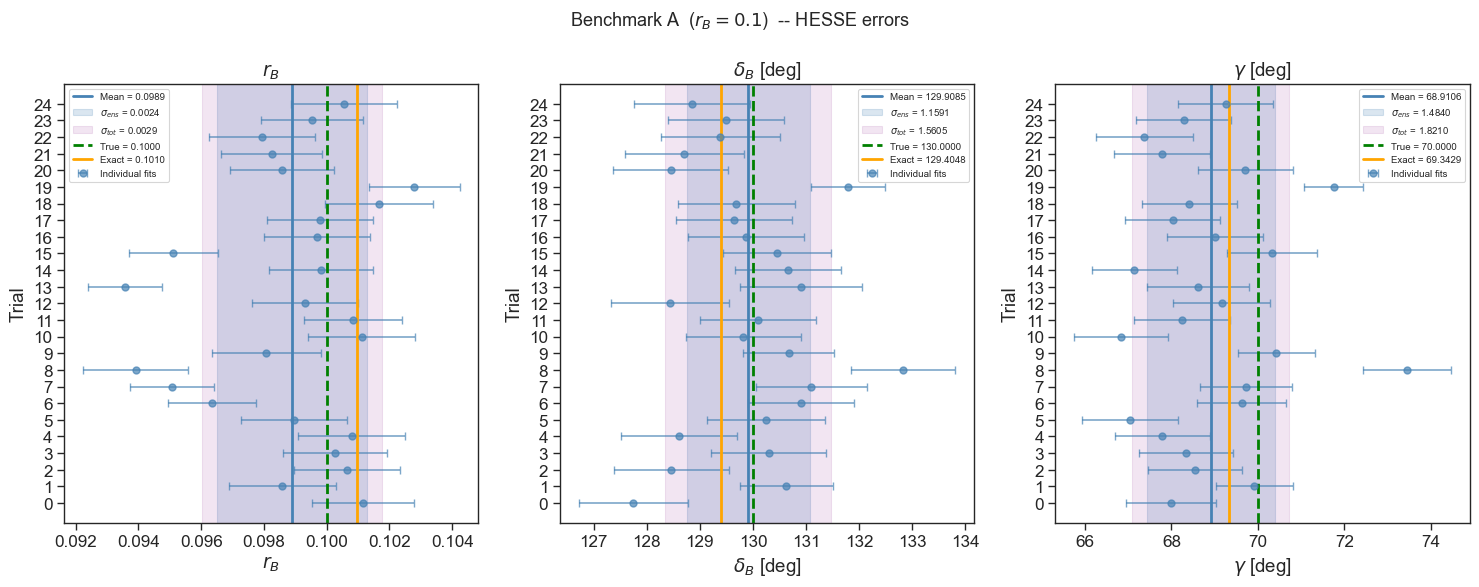

In [36]:
# ============================================================================
# Ensemble fit plots: HESSE and Profile Likelihood (separate functions)
# ============================================================================

def plot_hesse_ensemble(
    flow_ens,
    true_rB, true_deltaB, true_gamma,
    m_exact=None,
    title='', save_path=None,
):
    """Horizontal error-bar plot for HESSE ensemble results."""
    valid = [r for r in flow_ens if r['valid']]

    exact_rB = exact_delta = exact_gamma = None
    if m_exact is not None:
        exact_rB    = m_exact.values['rB']
        exact_delta = m_exact.values['delta']
        exact_gamma = m_exact.values['gamma']

    params = [
        ([r['rB']    for r in valid], [r['err_rB']    for r in valid],
         r'$r_B$',            true_rB,     exact_rB),
        ([r['delta'] for r in valid], [r['err_delta'] for r in valid],
         r'$\delta_B$ [deg]', true_deltaB, exact_delta),
        ([r['gamma'] for r in valid], [r['err_gamma'] for r in valid],
         r'$\gamma$ [deg]',   true_gamma,  exact_gamma),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(title, fontsize=13)

    for ax, (vals, errs, label, true_val, exact_val) in zip(axes, params):
        vals  = np.array(vals)
        errs  = np.array(errs)
        y_pos = np.arange(len(vals))

        mean_val    = vals.mean()
        sigma_ens   = vals.std()
        sigma_fit   = errs.mean()
        sigma_total = np.sqrt(sigma_ens**2 + sigma_fit**2)

        ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='steelblue',
                    capsize=3, markersize=5, alpha=0.7, label='Individual fits')
        ax.axvline(mean_val, color='steelblue', linestyle='-', linewidth=2,
                   label=f'Mean = {mean_val:.4f}')
        ax.axvspan(mean_val - sigma_ens,   mean_val + sigma_ens,
                   alpha=0.20, color='steelblue',
                   label=f'$\\sigma_{{ens}}$ = {sigma_ens:.4f}')
        ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
                   alpha=0.10, color='purple',
                   label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
        ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
                   label=f'True = {true_val:.4f}')
        if exact_val is not None:
            ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
                       label=f'Exact = {exact_val:.4f}')

        ax.set_ylabel('Trial')
        ax.set_xlabel(label)
        ax.set_title(label)
        ax.set_yticks(y_pos)
        ax.legend(fontsize=7, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_profile_ensemble(
    flow_prof,
    true_rB, true_deltaB, true_gamma,
    m_exact=None,
    title='', save_path=None,
):
    """Horizontal asymmetric error-bar plot for profile-likelihood ensemble results."""
    valid = [r for r in flow_prof if r['valid']]

    exact_rB = exact_delta = exact_gamma = None
    if m_exact is not None:
        exact_rB    = m_exact.values['rB']
        exact_delta = m_exact.values['delta']
        exact_gamma = m_exact.values['gamma']

    params = [
        ([r['rB']    for r in valid],
         [r['prof_rB']['err_lo']    for r in valid],
         [r['prof_rB']['err_hi']    for r in valid],
         r'$r_B$',            true_rB,     exact_rB),
        ([r['delta'] for r in valid],
         [r['prof_delta']['err_lo'] for r in valid],
         [r['prof_delta']['err_hi'] for r in valid],
         r'$\delta_B$ [deg]', true_deltaB, exact_delta),
        ([r['gamma'] for r in valid],
         [r['prof_gamma']['err_lo'] for r in valid],
         [r['prof_gamma']['err_hi'] for r in valid],
         r'$\gamma$ [deg]',   true_gamma,  exact_gamma),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(title, fontsize=13)

    for ax, (vals, err_lo, err_hi, label, true_val, exact_val) in zip(axes, params):
        vals   = np.array(vals)
        err_lo = np.array(err_lo)
        err_hi = np.array(err_hi)
        y_pos  = np.arange(len(vals))

        mean_val    = vals.mean()
        sigma_ens   = vals.std()
        sigma_fit   = np.mean((err_lo + err_hi) / 2)
        sigma_total = np.sqrt(sigma_ens**2 + sigma_fit**2)

        ax.errorbar(vals, y_pos, xerr=[err_lo, err_hi], fmt='o', color='tomato',
                    capsize=3, markersize=5, alpha=0.7, label='Individual fits')
        ax.axvline(mean_val, color='tomato', linestyle='-', linewidth=2,
                   label=f'Mean = {mean_val:.4f}')
        ax.axvspan(mean_val - sigma_ens,   mean_val + sigma_ens,
                   alpha=0.20, color='tomato',
                   label=f'$\\sigma_{{ens}}$ = {sigma_ens:.4f}')
        ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
                   alpha=0.10, color='purple',
                   label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
        ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
                   label=f'True = {true_val:.4f}')
        if exact_val is not None:
            ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
                       label=f'Exact = {exact_val:.4f}')

        ax.set_ylabel('Trial')
        ax.set_xlabel(label)
        ax.set_title(label)
        ax.set_yticks(y_pos)
        ax.legend(fontsize=7, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# --- Benchmark A (rB = 0.1) ---
print('=== Benchmark A - HESSE ===')
plot_hesse_ensemble(
    flow_ens_A_avg,
    true_rB=0.1, true_deltaB=130.0, true_gamma=70.0,
    m_exact=m_A_exact,
    title=r'Benchmark A  ($r_B = 0.1$)  -- HESSE errors',
    save_path='ensemble_fit_results_A_hesse.pdf',
)

# print('=== Benchmark A - Profile LH ===')
# plot_profile_ensemble(
#     flow_prof_A,
#     true_rB=0.1, true_deltaB=130.0, true_gamma=70.0,
#     m_exact=m_A_exact,
#     title=r'Benchmark A  ($r_B = 0.1$)  -- Profile-likelihood errors',
#     save_path='ensemble_fit_results_A_profile.pdf',
# )


In [37]:
# Save flow ensemble results
valid = [r for r in flow_ens_A_avg if r["valid"]]
np.savez('fit_results_4_15.npz',
         results_rB    = np.array([r['rB']        for r in valid]),
         results_delta = np.array([r['delta']      for r in valid]),
         results_gamma = np.array([r['gamma']      for r in valid]),
         errors_rB     = np.array([r['err_rB']     for r in valid]),
         errors_delta  = np.array([r['err_delta']  for r in valid]),
         errors_gamma  = np.array([r['err_gamma']  for r in valid]))


In [38]:
np.savez('fit_results_exact.npz',
         results_rB    = np.array([m_A_exact.values['rB']]),
         results_delta = np.array([m_A_exact.values['delta']]),
         results_gamma = np.array([m_A_exact.values['gamma']]),
         errors_rB     = np.array([m_A_exact.errors['rB']]),
         errors_delta  = np.array([m_A_exact.errors['delta']]),
         errors_gamma  = np.array([m_A_exact.errors['gamma']]))


---
## 14. Varying B-data: Bias and Uncertainty over Multiple Pseudo-experiments

Fix the true physics point (Benchmark A); generate **N_Bdata** independent $B^\pm$
pseudo-datasets.  For each dataset:

1. Run the full 25-flow ensemble fit → flow-based $r_B$, $\delta_B$, $\gamma$
2. Run the exact isobar fit → reference $r_B$, $\delta_B$, $\gamma$
3. Record per-dataset bias = (fitted − true) and pull = (fitted − true) / $\sigma$

This lets us study:
- **Mean bias** and **RMS** of the flow-based and isobar estimators
- **Pull distributions** (should be unit-Gaussian if errors are correct)
- **Coverage** of the HESSE uncertainties

In [37]:
# ── Configuration ──────────────────────────────────────────────────────────
N_Bdata    = 20        # number of independent B pseudo-datasets
N_exp      = 100_000   # events per charge per dataset
N_mc       = 1_000_000 # MC events per charge

true_rB_vary    = 0.1
true_deltaB_vary = 130.0   # degrees
true_gamma_vary  =  70.0   # degrees

save_dir = Path('varying_Bdata_results')
save_dir.mkdir(exist_ok=True)

In [38]:
# ── Generate B datasets & run ensemble + exact fits for each ───────────────
# Resumes automatically: skips any B-dataset whose .npz already exists.
all_flow_ensemble_results = []   # list of lists (one per B-dataset)
all_exact_results = []           # list of dicts  (one per B-dataset)

for ib in range(N_Bdata):
    out_path = save_dir / f'Bdata_{ib:03d}.npz'

    # ── Skip if already completed ──────────────────────────────────────
    if out_path.exists():
        print(f'B-dataset {ib+1}/{N_Bdata} — already saved, loading from {out_path}')
        d = np.load(out_path)
        n_valid = len(d['flow_rB'])
        ens_loaded = [dict(
            rB=d['flow_rB'][j],        err_rB=d['flow_err_rB'][j],
            delta=d['flow_delta'][j],  err_delta=d['flow_err_delta'][j],
            gamma=d['flow_gamma'][j],  err_gamma=d['flow_err_gamma'][j],
            valid=True,
        ) for j in range(n_valid)]
        all_flow_ensemble_results.append(ens_loaded)
        all_exact_results.append(dict(
            rB=float(d['exact_rB']),       err_rB=float(d['exact_err_rB']),
            delta=float(d['exact_delta']), err_delta=float(d['exact_err_delta']),
            gamma=float(d['exact_gamma']), err_gamma=float(d['exact_err_gamma']),
            valid=True,
        ))
        continue

    print(f'\n{"="*70}')
    print(f'  B-dataset {ib+1}/{N_Bdata}')
    print(f'{"="*70}')

    # 1. Generate B+/B- pseudo-data with a new random seed each time
    samples_ib = generate_BpBm_samples(
        rB     = true_rB_vary,
        deltaB = np.radians(true_deltaB_vary),
        gamma  = np.radians(true_gamma_vary),
        N_exp  = N_exp,
        N_mc   = N_mc,
    )

    # 2. Flow ensemble fit (25 flow triplets)
    print(f'\n--- Flow ensemble fit for B-dataset {ib+1} ---')
    ens_results_ib = run_flow_ensemble_fits(
        dataM_sdp   = samples_ib['dataM_sdp'],
        dataP_sdp   = samples_ib['dataP_sdp'],
        mcM_sdp     = samples_ib['mcM_sdp'],
        mcP_sdp     = samples_ib['mcP_sdp'],
        flavor_dir  = 'flavor_SDP_sym_2e6',
        even_dir    = 'even_SDP_sym_2e6',
        odd_dir     = 'odd_SDP_sym_2e6',
        true_rB     = true_rB_vary,
        true_deltaB = true_deltaB_vary,
        true_gamma  = true_gamma_vary,
        constraint  = 'knn_v4',
        K_init      = 2,
        K_max       = 8000,
    )
    summarise_flow_ensemble(ens_results_ib, true_rB_vary, true_deltaB_vary, true_gamma_vary)
    all_flow_ensemble_results.append(ens_results_ib)

    # 3. Exact isobar fit (reference)
    print(f'\n--- Exact isobar fit for B-dataset {ib+1} ---')
    m_exact_ib, _ = fit_gamma_exact(
        dataM_sdp   = samples_ib['dataM_sdp'],
        dataP_sdp   = samples_ib['dataP_sdp'],
        mcM_sdp     = samples_ib['mcM_sdp'],
        mcP_sdp     = samples_ib['mcP_sdp'],
        true_rB     = true_rB_vary,
        true_deltaB = true_deltaB_vary,
        true_gamma  = true_gamma_vary,
    )
    all_exact_results.append(dict(
        rB=m_exact_ib.values['rB'],       err_rB=m_exact_ib.errors['rB'],
        delta=m_exact_ib.values['delta'], err_delta=m_exact_ib.errors['delta'],
        gamma=m_exact_ib.values['gamma'], err_gamma=m_exact_ib.errors['gamma'],
        valid=m_exact_ib.valid,
    ))

    # 4. Save per-B-dataset results + raw B samples incrementally
    valid_ens = [r for r in ens_results_ib if r['valid']]
    np.savez(
        out_path,
        # B-data samples (so you can re-run fits without regenerating)
        dataM_sdp  = samples_ib['dataM_sdp'],
        dataP_sdp  = samples_ib['dataP_sdp'],
        mcM_sdp    = samples_ib['mcM_sdp'],
        mcP_sdp    = samples_ib['mcP_sdp'],
        # flow ensemble
        flow_rB       = np.array([r['rB']        for r in valid_ens]),
        flow_delta    = np.array([r['delta']      for r in valid_ens]),
        flow_gamma    = np.array([r['gamma']      for r in valid_ens]),
        flow_err_rB   = np.array([r['err_rB']     for r in valid_ens]),
        flow_err_delta= np.array([r['err_delta']  for r in valid_ens]),
        flow_err_gamma= np.array([r['err_gamma']  for r in valid_ens]),
        # exact isobar
        exact_rB       = m_exact_ib.values['rB'],
        exact_delta    = m_exact_ib.values['delta'],
        exact_gamma    = m_exact_ib.values['gamma'],
        exact_err_rB   = m_exact_ib.errors['rB'],
        exact_err_delta= m_exact_ib.errors['delta'],
        exact_err_gamma= m_exact_ib.errors['gamma'],
    )
    print(f'  Saved {out_path}')

print(f'\nDone — {N_Bdata} B-datasets processed.')

B-dataset 1/20 — already saved, loading from varying_Bdata_results\Bdata_000.npz
B-dataset 2/20 — already saved, loading from varying_Bdata_results\Bdata_001.npz
B-dataset 3/20 — already saved, loading from varying_Bdata_results\Bdata_002.npz
B-dataset 4/20 — already saved, loading from varying_Bdata_results\Bdata_003.npz
B-dataset 5/20 — already saved, loading from varying_Bdata_results\Bdata_004.npz

  B-dataset 6/20
Generating B- data...
  100,000 events in 16.1s
Generating B+ data...
  100,000 events in 15.0s

--- Flow ensemble fit for B-dataset 6 ---
Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Applying constraint: knn_v4
    KNN-v4: 18649 / 100000 violations (18.6%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 1146 points discarded (K > 8000)
    KNN-v4: 17285 / 100000 violations (17.3%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 928 points discarded (K > 8000)
    KNN-v4: 180829 / 1000000 violations (18.1%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 38597 points discarded (K > 8000)
    KNN-v4: 180463 / 1000000 violations (18.0%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 37973 points discarded (K > 8000)
Fit time: 2.5s | valid: True
  rB    = 0.0976 +/- 0.0017  (true: 0.1)
  delta = 129.88 +/- 1.03 deg  (true: 130.0)
  gamma = 69.21 +/- 1.03 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn_v4
    KNN-v4: 17034 / 100000 violations (17.0%), smoothing via MC neighbors (C + abJ)...
    KNN-v4: 1639 points discarded (K > 8000)
    KNN-v

### 14.1 Reload saved results (optional — run this instead of the loop above)

In [ ]:
# ── Reload from disk ───────────────────────────────────────────────────────
save_dir = Path('varying_Bdata_results')
# from 0 to 18.
files = sorted(save_dir.glob('Bdata_*.npz'))[:19]
print(f'Found {len(files)} saved B-dataset result files.')

all_flow_ensemble_results = []
all_exact_results = []

for f in files:
    d = np.load(f)
    # Rebuild flow ensemble list-of-dicts
    ens = [dict(rB=d['flow_rB'][j], err_rB=d['flow_err_rB'][j],
                delta=d['flow_delta'][j], err_delta=d['flow_err_delta'][j],
                gamma=d['flow_gamma'][j], err_gamma=d['flow_err_gamma'][j],
                valid=True)
           for j in range(len(d['flow_rB']))]
    all_flow_ensemble_results.append(ens)
    all_exact_results.append(dict(
        rB=float(d['exact_rB']),       err_rB=float(d['exact_err_rB']),
        delta=float(d['exact_delta']), err_delta=float(d['exact_err_delta']),
        gamma=float(d['exact_gamma']), err_gamma=float(d['exact_err_gamma']),
        valid=True,
    ))

true_rB_vary     = 0.1
true_deltaB_vary = 130.0
true_gamma_vary  =  70.0
N_Bdata = len(files)
print(f'Loaded {N_Bdata} B-datasets.')

Found 19 saved B-dataset result files.
Loaded 19 B-datasets.


### 14.2 Aggregate statistics across B-datasets

In [3]:
# ── Per-B-dataset summary: ensemble mean & std, exact values, biases ──────
truths = dict(rB=true_rB_vary, delta=true_deltaB_vary, gamma=true_gamma_vary)

# Flow ensemble: for each B-dataset, compute mean & std over the 25 flows
flow_mean  = {p: [] for p in ('rB', 'delta', 'gamma')}
flow_std   = {p: [] for p in ('rB', 'delta', 'gamma')}
flow_sigma_fit = {p: [] for p in ('rB', 'delta', 'gamma')}

for ens in all_flow_ensemble_results:
    valid = [r for r in ens if r['valid']]
    for p in ('rB', 'delta', 'gamma'):
        vals = np.array([r[p] for r in valid])
        errs = np.array([r[f'err_{p}'] for r in valid])
        flow_mean[p].append(vals.mean())
        flow_std[p].append(vals.std())
        flow_sigma_fit[p].append(errs.mean())

for p in ('rB', 'delta', 'gamma'):
    flow_mean[p]      = np.array(flow_mean[p])
    flow_std[p]       = np.array(flow_std[p])
    flow_sigma_fit[p] = np.array(flow_sigma_fit[p])

# Exact isobar
exact_val = {p: np.array([r[p] for r in all_exact_results]) for p in ('rB', 'delta', 'gamma')}
exact_err = {p: np.array([r[f'err_{p}'] for r in all_exact_results]) for p in ('rB', 'delta', 'gamma')}

# --- Bias relative to truth ---
flow_bias  = {p: flow_mean[p] - truths[p] for p in truths}
exact_bias = {p: exact_val[p] - truths[p] for p in truths}

# --- Bias relative to exact isobar (isolates flow model effect) ---
flow_vs_exact_bias = {p: flow_mean[p] - exact_val[p] for p in truths}

# Pulls (using total uncertainty for flow, HESSE for exact)
flow_sigma_total = {p: np.sqrt(flow_sigma_fit[p]**2 + flow_std[p]**2) for p in truths}
flow_pull  = {p: flow_bias[p] / flow_sigma_total[p] for p in truths}
exact_pull = {p: exact_bias[p] / exact_err[p] for p in truths}

# Print summary table — bias relative to truth
print('=== Bias relative to truth ===')
print(f'{"Parameter":<10} {"Method":<8} {"Mean bias":>12} {"RMS bias":>12} '
      f'{"Mean pull":>12} {"Pull RMS":>12}')
print('=' * 70)
for p, label in [('rB', 'rB'), ('delta', 'delta_B'), ('gamma', 'gamma')]:
    print(f'{label:<10} {"Flow":<8} {flow_bias[p].mean():>12.4f} '
          f'{np.sqrt((flow_bias[p]**2).mean()):>12.4f} '
          f'{flow_pull[p].mean():>12.3f} {flow_pull[p].std():>12.3f}')
    print(f'{"":<10} {"Exact":<8} {exact_bias[p].mean():>12.4f} '
          f'{np.sqrt((exact_bias[p]**2).mean()):>12.4f} '
          f'{exact_pull[p].mean():>12.3f} {exact_pull[p].std():>12.3f}')

# Print summary table — flow vs exact (isolates flow model bias)
print('\n=== Flow bias relative to exact isobar (flow model effect) ===')
print(f'{"Parameter":<10} {"Mean":>12} {"Std":>12} {"Mean/Std":>12}')
print('=' * 50)
for p, label in [('rB', 'rB'), ('delta', 'delta_B'), ('gamma', 'gamma')]:
    m = flow_vs_exact_bias[p].mean()
    s = flow_vs_exact_bias[p].std()
    print(f'{label:<10} {m:>12.4f} {s:>12.4f} {m/s if s > 0 else 0:>12.2f}')

=== Bias relative to truth ===
Parameter  Method      Mean bias     RMS bias    Mean pull     Pull RMS
rB         Flow          -0.0018       0.0026       -0.649        0.738
           Exact         -0.0003       0.0018       -0.155        1.047
delta_B    Flow           0.4592       1.7265        0.150        0.882
           Exact         -0.1786       1.4163       -0.153        1.239
gamma      Flow          -0.3541       1.2415       -0.229        0.633
           Exact          0.1588       1.2012        0.149        1.071

=== Flow bias relative to exact isobar (flow model effect) ===
Parameter          Mean          Std     Mean/Std
rB              -0.0015       0.0004        -3.61
delta_B          0.6379       0.5773         1.10
gamma           -0.5129       0.5133        -1.00


### 14.3 Bias and pull distributions across B-datasets

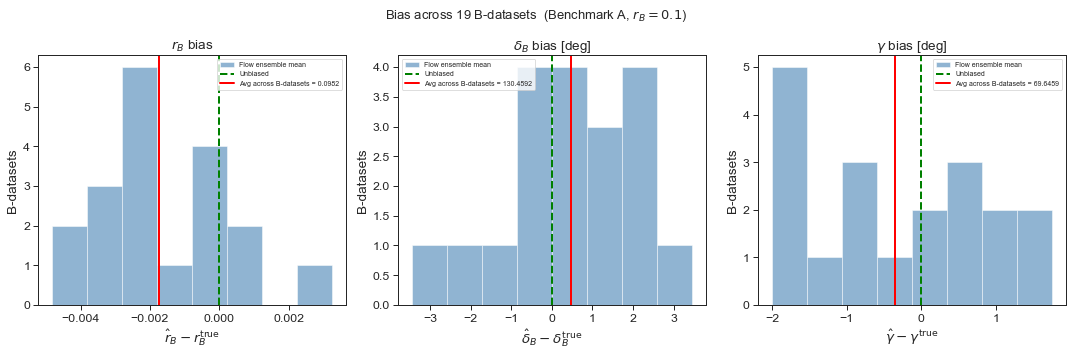

In [12]:
# ── Bias distribution plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Bias across {N_Bdata} B-datasets  (Benchmark A, $r_B={true_rB_vary}$)', fontsize=13)

param_info = [
    ('rB',    r'$r_B$ bias',            r'$\hat{r}_B - r_B^{\mathrm{true}}$'),
    ('delta', r'$\delta_B$ bias [deg]', r'$\hat{\delta}_B - \delta_B^{\mathrm{true}}$'),
    ('gamma', r'$\gamma$ bias [deg]',   r'$\hat{\gamma} - \gamma^{\mathrm{true}}$'),
]

for ax, (p, title, xlabel) in zip(axes, param_info):
    ax.hist(flow_bias[p],  bins=8, alpha=0.6, color='steelblue', label='Flow ensemble mean')
    ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Unbiased')
    ax.axvline(flow_bias[p].mean(),  color='red', linestyle='-', linewidth=2,
               label=f'Avg across B-datasets = {flow_mean[p].mean():.4f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('B-datasets')
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('varying_Bdata_bias.pdf', dpi=150, bbox_inches='tight')
plt.show()

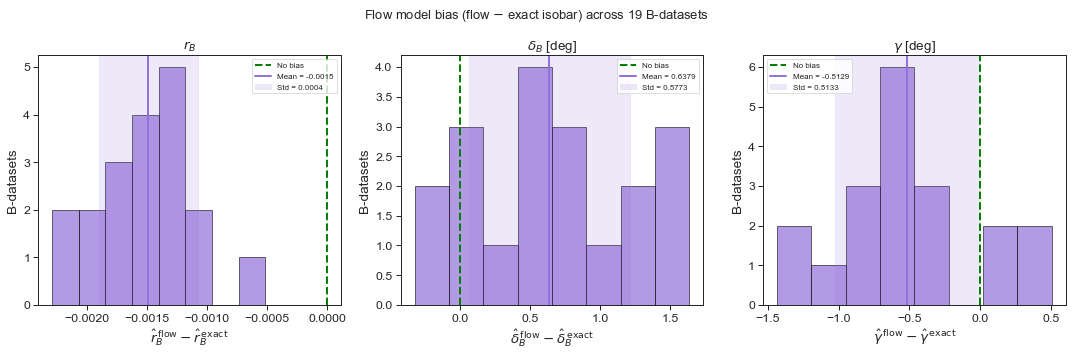

In [13]:
# ── Flow vs Exact bias (isolates the flow model effect) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Flow model bias (flow $-$ exact isobar) across {N_Bdata} B-datasets', fontsize=13)

param_info_vs = [
    ('rB',    r'$r_B$',            r'$\hat{r}_B^{\,\mathrm{flow}} - \hat{r}_B^{\,\mathrm{exact}}$'),
    ('delta', r'$\delta_B$ [deg]', r'$\hat{\delta}_B^{\,\mathrm{flow}} - \hat{\delta}_B^{\,\mathrm{exact}}$'),
    ('gamma', r'$\gamma$ [deg]',   r'$\hat{\gamma}^{\,\mathrm{flow}} - \hat{\gamma}^{\,\mathrm{exact}}$'),
]

for ax, (p, title, xlabel) in zip(axes, param_info_vs):
    d = flow_vs_exact_bias[p]
    ax.hist(d, bins=8, alpha=0.7, color='mediumpurple', edgecolor='k')
    ax.axvline(0, color='green', linestyle='--', linewidth=2, label='No bias')
    ax.axvline(d.mean(), color='mediumpurple', linestyle='-', linewidth=2,
               label=f'Mean = {d.mean():.4f}')
    ax.axvspan(d.mean() - d.std(), d.mean() + d.std(),
               alpha=0.15, color='mediumpurple',
               label=f'Std = {d.std():.4f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('B-datasets')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('varying_Bdata_flow_vs_exact_bias.pdf', dpi=150, bbox_inches='tight')
plt.show()

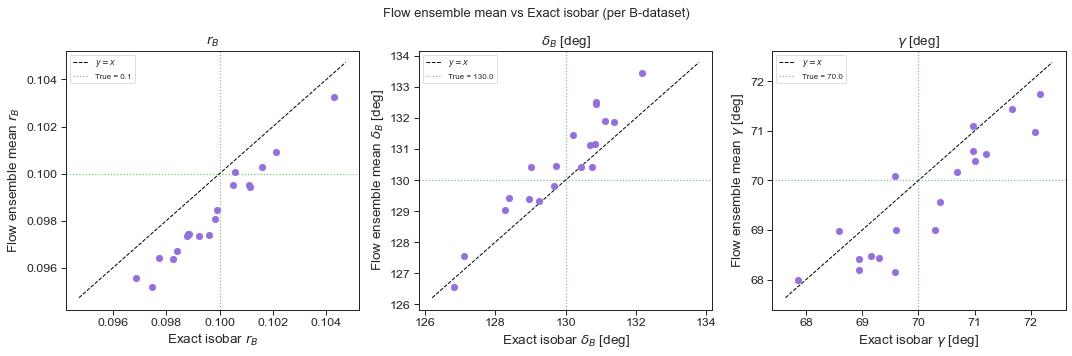

In [14]:
# ── Flow vs Exact correlation: scatter plot ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Flow ensemble mean vs Exact isobar (per B-dataset)', fontsize=13)

for ax, (p, label, true_val) in zip(axes, [
    ('rB',    r'$r_B$',            true_rB_vary),
    ('delta', r'$\delta_B$ [deg]', true_deltaB_vary),
    ('gamma', r'$\gamma$ [deg]',   true_gamma_vary),
]):
    ax.scatter(exact_val[p], flow_mean[p], color='mediumpurple', s=40, zorder=3)
    # diagonal (perfect agreement)
    lo = min(exact_val[p].min(), flow_mean[p].min())
    hi = max(exact_val[p].max(), flow_mean[p].max())
    margin = 0.05 * (hi - lo)
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            'k--', linewidth=1, label='$y = x$')
    ax.axhline(true_val, color='green', linestyle=':', alpha=0.5, label=f'True = {true_val}')
    ax.axvline(true_val, color='green', linestyle=':', alpha=0.5)
    ax.set_xlabel(f'Exact isobar {label}')
    ax.set_ylabel(f'Flow ensemble mean {label}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('varying_Bdata_flow_vs_exact_scatter.pdf', dpi=150, bbox_inches='tight')
plt.show()

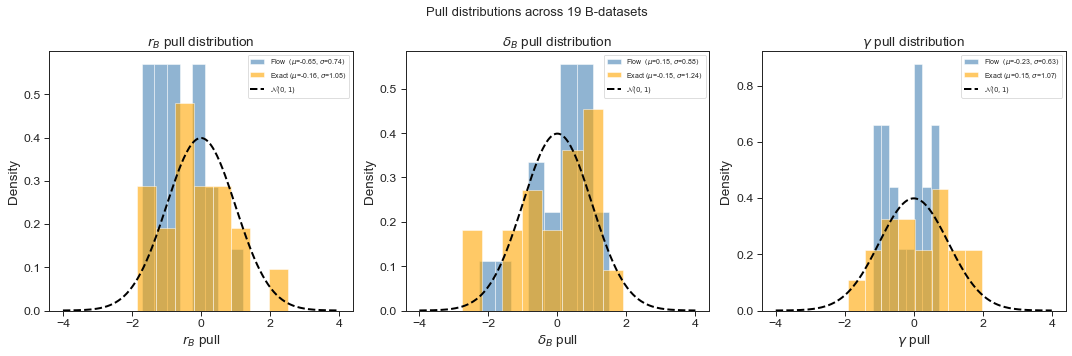

In [15]:
# ── Pull distribution plot ─────────────────────────────────────────────────
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Pull distributions across {N_Bdata} B-datasets', fontsize=13)

param_labels = [('rB', r'$r_B$'), ('delta', r'$\delta_B$'), ('gamma', r'$\gamma$')]

for ax, (p, label) in zip(axes, param_labels):
    ax.hist(flow_pull[p],  bins=8, alpha=0.6, density=True, color='steelblue',
            label=f'Flow  ($\\mu$={flow_pull[p].mean():.2f}, $\\sigma$={flow_pull[p].std():.2f})')
    ax.hist(exact_pull[p], bins=8, alpha=0.6, density=True, color='orange',
            label=f'Exact ($\\mu$={exact_pull[p].mean():.2f}, $\\sigma$={exact_pull[p].std():.2f})')
    x = np.linspace(-4, 4, 200)
    ax.plot(x, norm.pdf(x), 'k--', linewidth=2, label=r'$\mathcal{N}(0,1)$')
    ax.set_xlabel(f'{label} pull')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} pull distribution')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('varying_Bdata_pulls.pdf', dpi=150, bbox_inches='tight')
plt.show()

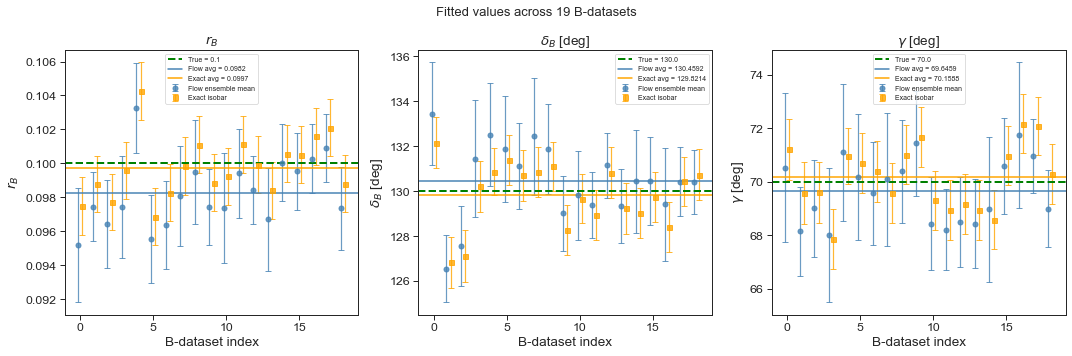

In [17]:
# ── Fitted values across B-datasets: scatter with error bars ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Fitted values across {N_Bdata} B-datasets', fontsize=13)

x_bdata = np.arange(N_Bdata)

for ax, (p, label, true_val) in zip(axes, [
    ('rB',    r'$r_B$',            true_rB_vary),
    ('delta', r'$\delta_B$ [deg]', true_deltaB_vary),
    ('gamma', r'$\gamma$ [deg]',   true_gamma_vary),
]):
    # Flow ensemble mean +/- sigma_total
    ax.errorbar(x_bdata - 0.15, flow_mean[p], yerr=flow_sigma_total[p],
                fmt='o', color='steelblue', capsize=3, markersize=5,
                alpha=0.8, label='Flow ensemble mean')
    # Exact isobar +/- HESSE
    ax.errorbar(x_bdata + 0.15, exact_val[p], yerr=exact_err[p],
                fmt='s', color='orange', capsize=3, markersize=5,
                alpha=0.8, label='Exact isobar')
    ax.axhline(true_val, color='green', linestyle='--', linewidth=2, label=f'True = {true_val}')
    ax.axhline(flow_mean[p].mean(), color='steelblue', linestyle='-', linewidth=1.5,
               label=f'Flow avg = {flow_mean[p].mean():.4f}')
    ax.axhline(exact_val[p].mean(), color='orange', linestyle='-', linewidth=1.5,
               label=f'Exact avg = {exact_val[p].mean():.4f}')

    ax.set_xlabel('B-dataset index')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('varying_Bdata_scatter.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ── Save aggregated results ────────────────────────────────────────────────
np.savez(
    save_dir / 'varying_Bdata_summary.npz',
    # Flow ensemble means over B-datasets
    flow_mean_rB    = flow_mean['rB'],
    flow_mean_delta = flow_mean['delta'],
    flow_mean_gamma = flow_mean['gamma'],
    flow_std_rB     = flow_std['rB'],
    flow_std_delta  = flow_std['delta'],
    flow_std_gamma  = flow_std['gamma'],
    flow_sigma_fit_rB    = flow_sigma_fit['rB'],
    flow_sigma_fit_delta = flow_sigma_fit['delta'],
    flow_sigma_fit_gamma = flow_sigma_fit['gamma'],
    # Exact isobar
    exact_rB        = exact_val['rB'],
    exact_delta     = exact_val['delta'],
    exact_gamma     = exact_val['gamma'],
    exact_err_rB    = exact_err['rB'],
    exact_err_delta = exact_err['delta'],
    exact_err_gamma = exact_err['gamma'],
    # Truths
    true_rB    = true_rB_vary,
    true_delta = true_deltaB_vary,
    true_gamma = true_gamma_vary,
)
print(f'Saved {save_dir}/varying_Bdata_summary.npz')

Saved varying_Bdata_results/varying_Bdata_summary.npz
